<a href="https://colab.research.google.com/github/Saurav-K-yadav/ml_learning/blob/main/customer_churn_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [67]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
alfathterry_telco_customer_churn_11_1_3_path = kagglehub.dataset_download('alfathterry/telco-customer-churn-11-1-3')

print('Data source import complete.')


Using Colab cache for faster access to the 'telco-customer-churn-11-1-3' dataset.
Data source import complete.


In [68]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/telco-customer-churn-11-1-3/telco.csv


In [69]:
# df=pd.read_csv('/kaggle/input/datasets/alfathterry/telco-customer-churn-11-1-3/telco.csv')

path = alfathterry_telco_customer_churn_11_1_3_path

# Import os to join the path with the filename
import os

# Combine the path with the file name
file_path = os.path.join(path, 'telco.csv')

# Load the dataframe
df = pd.read_csv(file_path)


In [70]:
df

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,Female,30,No,No,No,No,0,United States,California,...,0,1639.44,3039.53,5,Stayed,No,45,5306,NaN,NaN
7039,6840-RESVB,Male,38,No,No,Yes,Yes,2,United States,California,...,0,865.20,2807.47,3,Stayed,No,59,2140,NaN,NaN
7040,2234-XADUH,Female,30,No,No,Yes,Yes,2,United States,California,...,0,2135.52,9453.04,4,Stayed,No,71,5560,NaN,NaN
7041,4801-JZAZL,Female,32,No,No,Yes,Yes,2,United States,California,...,0,0.00,319.21,4,Stayed,No,59,2793,NaN,NaN


In [71]:
print(df.info())
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Under 30                           7043 non-null   object 
 4   Senior Citizen                     7043 non-null   object 
 5   Married                            7043 non-null   object 
 6   Dependents                         7043 non-null   object 
 7   Number of Dependents               7043 non-null   int64  
 8   Country                            7043 non-null   object 
 9   State                              7043 non-null   object 
 10  City                               7043 non-null   object 
 11  Zip Code                           7043 non-null   int64

,Age,Number of Dependents,Zip Code,Latitude,Longitude,Population,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Churn Score,CLTV
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,46.509726,0.468692,93486.070567,36.197455,-119.756684,22139.603294,1.951867,32.386767,22.958954,20.515405,64.761692,2280.381264,1.962182,6.860713,749.099262,3034.379056,3.244924,58.505040,4400.295755
std,16.750352,0.962802,1856.767505,2.468929,2.154425,21152.392837,3.001199,24.542061,15.448113,20.418940,30.090047,2266.220462,7.902614,25.104978,846.660055,2865.204542,1.201657,21.170031,1183.057152
min,19.000000,0.000000,90001.000000,32.555828,-124.301372,11.000000,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.000000,0.000000,0.000000,21.360000,1.000000,5.000000,2003.000000
25%,32.000000,0.000000,92101.000000,33.990646,-121.788090,2344.000000,0.000000,9.000000,9.210000,3.000000,35.500000,400.150000,0.000000,0.000000,70.545000,605.610000,3.000000,40.000000,3469.000000
50%,46.000000,0.000000,93518.000000,36.205465,-119.595293,17554.000000,0.000000,29.000000,22.890000,17.000000,70.350000,1394.550000,0.000000,0.000000,401.440000,2108.640000,3.000000,61.000000,4527.000000
75%,60.000000,0.000000,95329.000000,38.161321,-117.969795,36125.000000,3.000000,55.000000,36.395000,27.000000,89.850000,3786.600000,0.000000,0.000000,1191.100000,4801.145000,4.000000,75.500000,5380.500000
max,80.000000,9.000000,96150.000000,41.962127,-114.192901,105285.000000,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000,5.000000,96.000000,6500.000000


In [72]:
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno


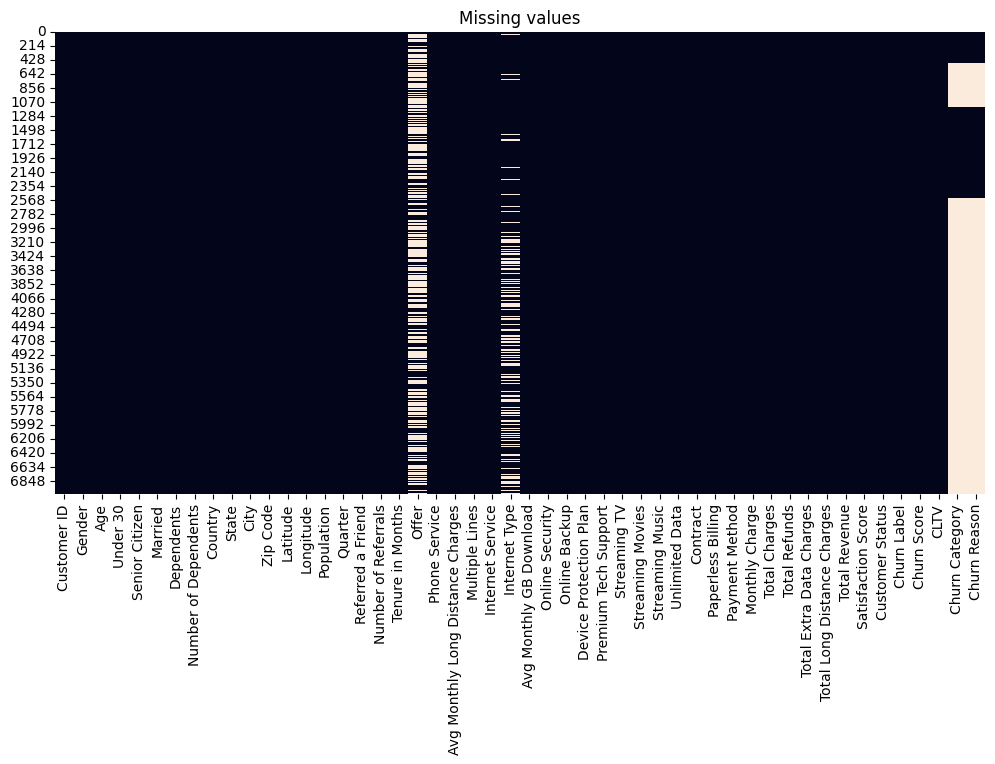

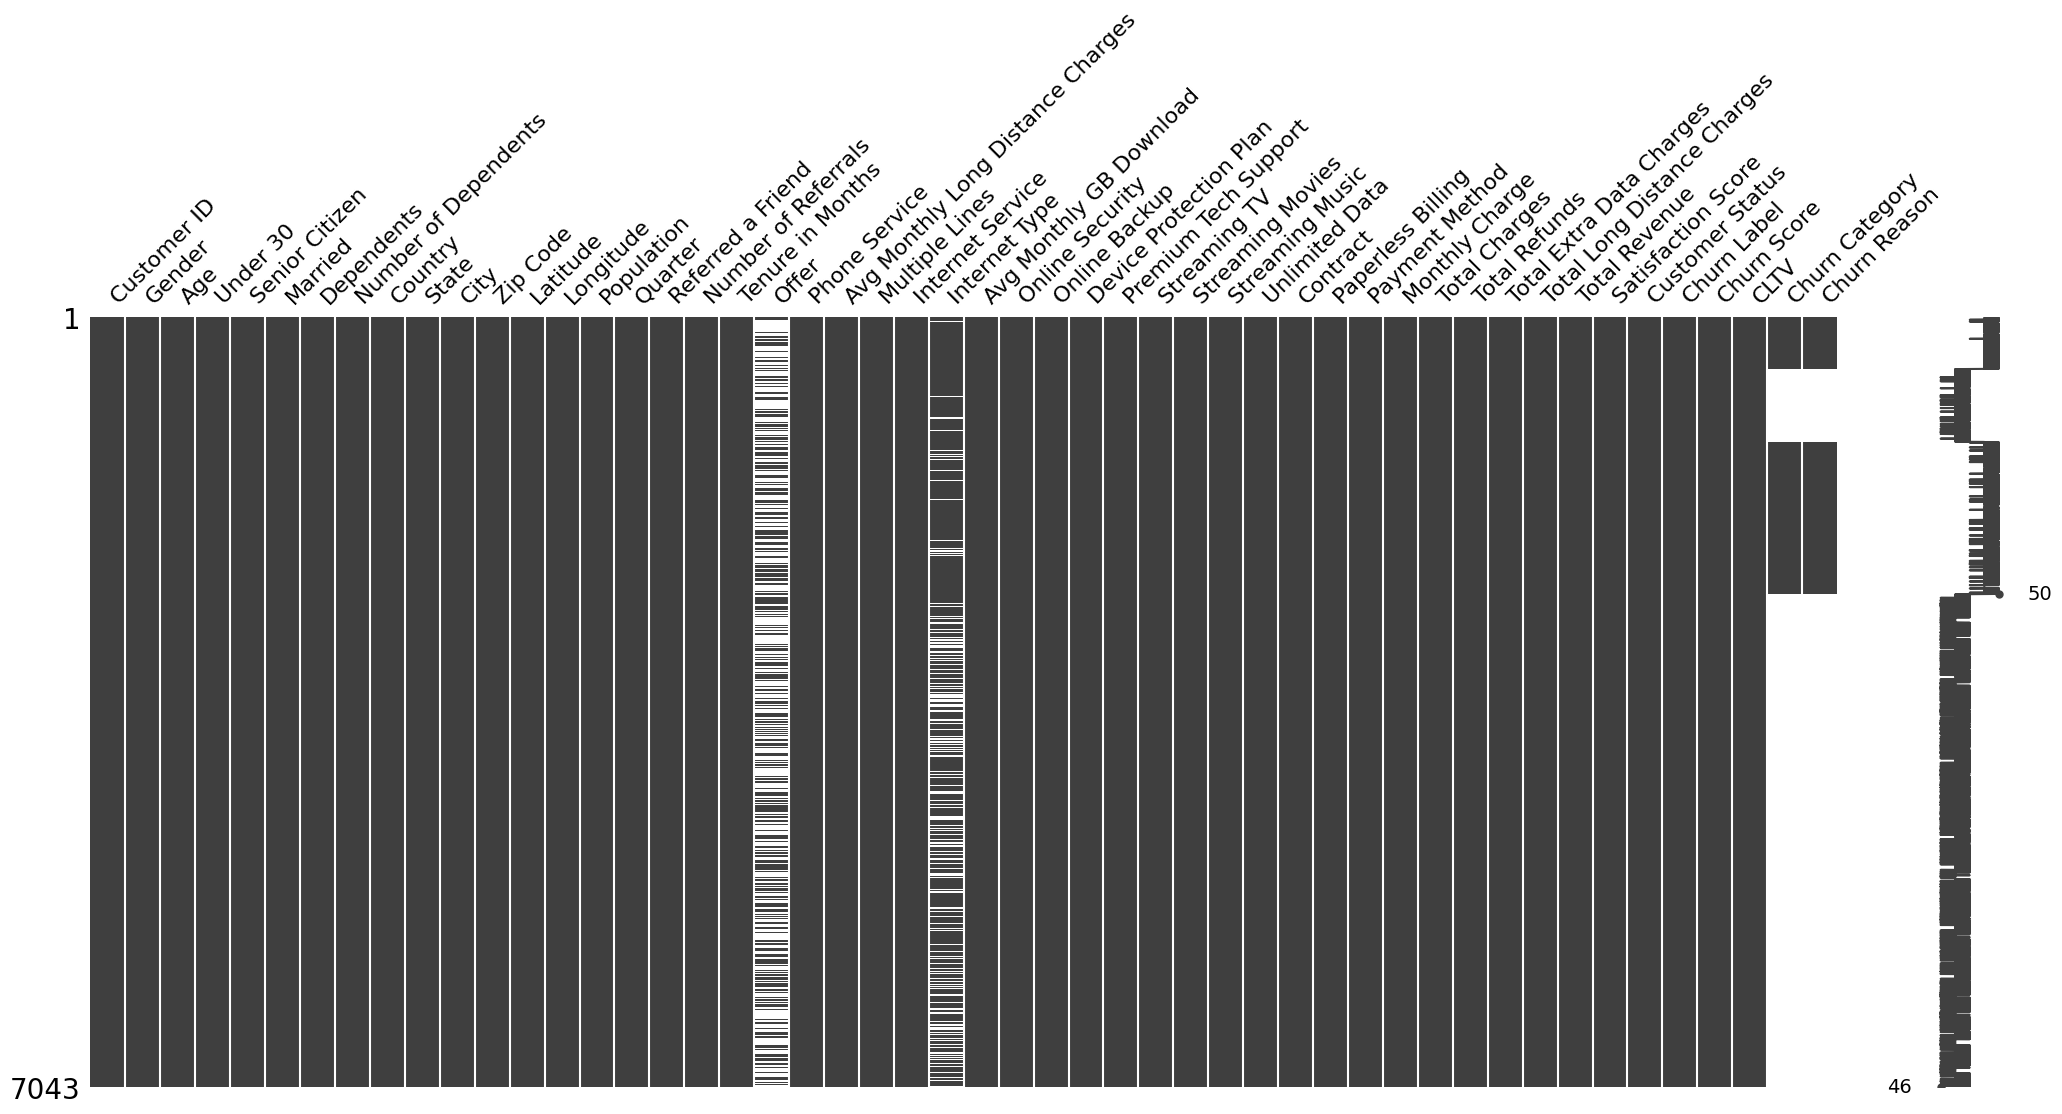

In [73]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(),cbar=False)
plt.title('Missing values')
plt.show()


msno.matrix(df)
plt.show()


In [74]:
# There is possibility of data-leakage as some columns defines churn label column. Removing these columns

cols=[
    'Customer Status',
    'Churn Category',
    'Churn Reason',
    'Churn Score'
]
df[cols].sample(100)

df.drop(cols,axis=1,inplace=True)

In [75]:
#since Satisfaction Score is giving high SHAP score checking what happens if i drop it
df.drop(['Satisfaction Score'],axis=1,inplace=True)

In [76]:
# Customer ID does not affect the outcome.
df=df.drop('Customer ID',axis=1)

In [77]:
print(df['Country'].unique(),df['State'].unique(),df['City'].unique())
df=df.drop(['Country','State'],axis=1)
df.sample(20)

['United States'] ['California'] ['Los Angeles' 'Inglewood' 'Whittier' ... 'Topaz' 'Jacumba' 'Holtville']


,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,City,Zip Code,Latitude,...,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Churn Label,CLTV
4788,Male,46,No,No,No,No,0,Glendale,91206,34.162515,...,No,Credit Card,59.90,542.40,38.33,10,96.21,610.28,No,5414
5978,Female,38,No,No,No,Yes,1,Desert Hot Springs,92241,33.832799,...,Yes,Bank Withdrawal,89.35,89.35,0.00,0,5.36,94.71,No,2432
3781,Male,49,No,No,No,No,0,Boulevard,91905,32.677097,...,No,Credit Card,19.20,908.15,0.00,0,1425.54,2333.69,No,2776
3523,Male,52,No,No,No,No,0,Redding,96003,40.677649,...,No,Bank Withdrawal,19.85,1434.10,0.00,0,246.96,1681.06,No,4790
4978,Male,30,No,No,Yes,No,0,Riverside,92504,33.910800,...,Yes,Bank Withdrawal,80.20,3581.60,0.00,0,1460.71,5042.31,No,5888
6821,Female,47,No,No,No,No,0,Malibu,90265,34.074572,...,Yes,Bank Withdrawal,74.65,3090.65,0.00,100,1274.28,4464.93,No,3859
6719,Female,55,No,No,No,No,0,Macdoel,96058,41.769709,...,No,Bank Withdrawal,64.35,2053.05,46.39,0,1549.04,3555.70,No,3445
4883,Male,47,No,No,No,No,0,Santa Ysabel,92070,33.174725,...,No,Bank Withdrawal,81.90,3219.75,0.00,0,1370.07,4589.82,No,3446
6829,Male,22,Yes,No,Yes,No,0,South Gate,90280,33.944624,...,Yes,Bank Withdrawal,106.30,7565.35,0.00,0,1086.48,8651.83,No,4634
6206,Male,31,No,No,No,No,0,Temecula,92592,33.507255,...,Yes,Credit Card,19.80,1311.30,0.00,0,316.24,1627.54,No,4260


In [78]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(df.sample(5
                   ))


      Gender  Age Under 30 Senior Citizen Married Dependents  \
3128    Male   23      Yes             No     Yes         No   
6039  Female   21      Yes             No     Yes        Yes   
6817  Female   48       No             No     Yes        Yes   
3045  Female   46       No             No     Yes         No   
6913  Female   49       No             No      No         No   

      Number of Dependents             City  Zip Code   Latitude   Longitude  \
3128                     0    San Francisco     94121  37.776718 -122.495781   
6039                     1        Riverside     92503  33.890046 -117.455583   
6817                     3  Huntington Park     90255  33.978030 -118.217141   
3045                     0           Clovis     93612  36.814539 -119.711868   
6913                     0         Van Nuys     91406  34.195685 -118.490752   

      Population Quarter Referred a Friend  Number of Referrals  \
3128       42476      Q3               Yes                    1   


In [79]:
print(df.isnull().sum())
# filling values in missing rows

df['Offer']=df['Offer'].fillna('No Offer')
df['Internet Type']=df['Internet Type'].fillna('No Internet')
print(df.isnull().sum())


Gender                                  0
Age                                     0
Under 30                                0
Senior Citizen                          0
Married                                 0
Dependents                              0
Number of Dependents                    0
City                                    0
Zip Code                                0
Latitude                                0
Longitude                               0
Population                              0
Quarter                                 0
Referred a Friend                       0
Number of Referrals                     0
Tenure in Months                        0
Offer                                3877
Phone Service                           0
Avg Monthly Long Distance Charges       0
Multiple Lines                          0
Internet Service                        0
Internet Type                        1526
Avg Monthly GB Download                 0
Online Security                   

In [80]:
df['Churn Label']= df['Churn Label'].replace({
    'Yes': 1,
    'No': 0
})


/tmp/ipykernel_18712/1808573179.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Churn Label']= df['Churn Label'].replace({


In [81]:

df

,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,City,Zip Code,Latitude,...,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Churn Label,CLTV
0,Male,78,No,Yes,No,No,0,Los Angeles,90022,34.023810,...,Yes,Bank Withdrawal,39.65,39.65,0.00,20,0.00,59.65,1,5433
1,Female,74,No,Yes,Yes,Yes,1,Los Angeles,90063,34.044271,...,Yes,Credit Card,80.65,633.30,0.00,0,390.80,1024.10,1,5302
2,Male,71,No,Yes,No,Yes,3,Los Angeles,90065,34.108833,...,Yes,Bank Withdrawal,95.45,1752.55,45.61,0,203.94,1910.88,1,3179
3,Female,78,No,Yes,Yes,Yes,1,Inglewood,90303,33.936291,...,Yes,Bank Withdrawal,98.50,2514.50,13.43,0,494.00,2995.07,1,5337
4,Female,80,No,Yes,Yes,Yes,1,Whittier,90602,33.972119,...,Yes,Bank Withdrawal,76.50,2868.15,0.00,0,234.21,3102.36,1,2793
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Female,30,No,No,No,No,0,Landers,92285,34.341737,...,Yes,Bank Withdrawal,21.15,1419.40,19.31,0,1639.44,3039.53,0,5306
7039,Male,38,No,No,Yes,Yes,2,Adelanto,92301,34.667815,...,Yes,Mailed Check,84.80,1990.50,48.23,0,865.20,2807.47,0,2140
7040,Female,30,No,No,Yes,Yes,2,Amboy,92304,34.559882,...,Yes,Credit Card,103.20,7362.90,45.38,0,2135.52,9453.04,0,5560
7041,Female,32,No,No,Yes,Yes,2,Angelus Oaks,92305,34.167800,...,Yes,Bank Withdrawal,29.60,346.45,27.24,0,0.00,319.21,0,2793


In [82]:

df.drop(columns=['Longitude','Latitude'],inplace=True,axis=1)

In [83]:
# service_cols = [
#     'Phone Service',
#     'Multiple Lines',
#     'Online Security',
#     'Online Backup',
#     'Device Protection Plan',
#     'Premium Tech Support',
#     'Streaming TV',
#     'Streaming Movies',
#     'Streaming Music',
#     'Unlimited Data'
# ]

# for col in service_cols:

#     df[col] = df[col].replace({
#         'Yes':1,
#         'No':0
#     })


In [84]:
y=df['Churn Label']
X=df.drop(columns=['Churn Label'])

In [85]:
categorical_cols=X.select_dtypes(include="object").columns
numerical_cols=X.select_dtypes(exclude="object").columns
categorical_cols,numerical_cols

(Index(['Gender', 'Under 30', 'Senior Citizen', 'Married', 'Dependents', 'City',
        'Quarter', 'Referred a Friend', 'Offer', 'Phone Service',
        'Multiple Lines', 'Internet Service', 'Internet Type',
        'Online Security', 'Online Backup', 'Device Protection Plan',
        'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
        'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
        'Payment Method'],
       dtype='object'),
 Index(['Age', 'Number of Dependents', 'Zip Code', 'Population',
        'Number of Referrals', 'Tenure in Months',
        'Avg Monthly Long Distance Charges', 'Avg Monthly GB Download',
        'Monthly Charge', 'Total Charges', 'Total Refunds',
        'Total Extra Data Charges', 'Total Long Distance Charges',
        'Total Revenue', 'CLTV'],
       dtype='object'))

In [86]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
OneHotEncoder,
StandardScaler)
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer


In [87]:
from sklearn.model_selection import train_test_split


<Axes: xlabel='Churn Label', ylabel='count'>

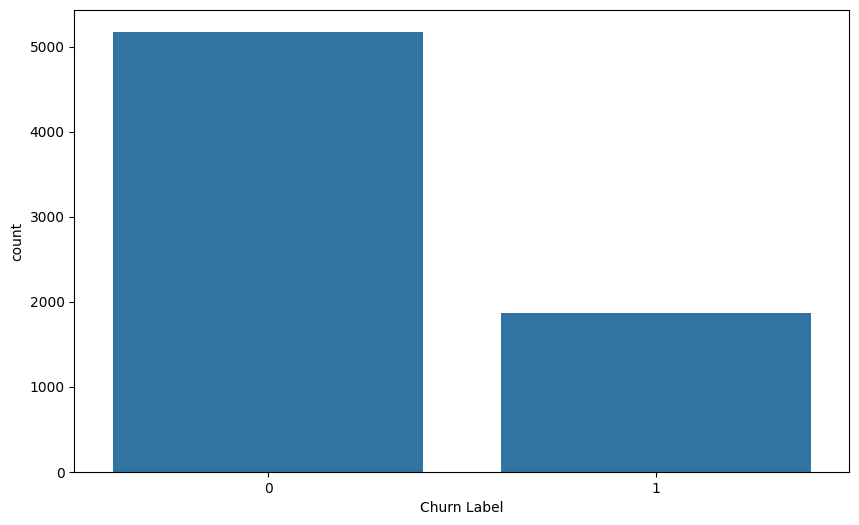

In [88]:
plt.figure(figsize=(10,6))
sns.countplot(
    x='Churn Label',
    data=df
)

In [89]:
Xtrain,Xtest,ytrain,ytest=train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y#due to imbalance
)

In [90]:
Xtrain.shape

(5282, 39)

In [91]:
for col in categorical_cols:
    print(f"{col}: {Xtrain[col].nunique()} unique categories")


Gender: 2 unique categories
Under 30: 2 unique categories
Senior Citizen: 2 unique categories
Married: 2 unique categories
Dependents: 2 unique categories
City: 1101 unique categories
Quarter: 1 unique categories
Referred a Friend: 2 unique categories
Offer: 6 unique categories
Phone Service: 2 unique categories
Multiple Lines: 2 unique categories
Internet Service: 2 unique categories
Internet Type: 4 unique categories
Online Security: 2 unique categories
Online Backup: 2 unique categories
Device Protection Plan: 2 unique categories
Premium Tech Support: 2 unique categories
Streaming TV: 2 unique categories
Streaming Movies: 2 unique categories
Streaming Music: 2 unique categories
Unlimited Data: 2 unique categories
Contract: 3 unique categories
Paperless Billing: 2 unique categories
Payment Method: 3 unique categories


In [92]:
pip install category_encoders


In [93]:
# City has 1101 unique values. One hot encoding will just alot of rows. using target encoding
import category_encoders as ce
targetEnc=ce.TargetEncoder(smoothing=10)
Xtrain['CityEncoded']=targetEnc.fit_transform(Xtrain['City'],ytrain)
Xtest['CityEncoded']=targetEnc.transform(Xtest['City'])
Xtrain=Xtrain.drop(columns=['City'])
Xtest=Xtest.drop(columns=['City'])

In [94]:
numerical_cols=list(numerical_cols)
categorical_cols=list(categorical_cols)
numerical_cols.append('CityEncoded')
categorical_cols=[r for r in categorical_cols if r!='City']

In [95]:
# need to scale the data
numericalTransform=Pipeline([
    ('imputer',SimpleImputer(strategy='median')),#missing values
    ('scaler',StandardScaler())
])

categoricalTransform=Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('encoder',OneHotEncoder(handle_unknown='ignore'))
])

preprocessor=ColumnTransformer([
    ('num',numericalTransform,numerical_cols),
    ('cat',categoricalTransform,categorical_cols)
])

In [96]:
categorical_cols,numerical_cols

(['Gender',
  'Under 30',
  'Senior Citizen',
  'Married',
  'Dependents',
  'Quarter',
  'Referred a Friend',
  'Offer',
  'Phone Service',
  'Multiple Lines',
  'Internet Service',
  'Internet Type',
  'Online Security',
  'Online Backup',
  'Device Protection Plan',
  'Premium Tech Support',
  'Streaming TV',
  'Streaming Movies',
  'Streaming Music',
  'Unlimited Data',
  'Contract',
  'Paperless Billing',
  'Payment Method'],
 ['Age',
  'Number of Dependents',
  'Zip Code',
  'Population',
  'Number of Referrals',
  'Tenure in Months',
  'Avg Monthly Long Distance Charges',
  'Avg Monthly GB Download',
  'Monthly Charge',
  'Total Charges',
  'Total Refunds',
  'Total Extra Data Charges',
  'Total Long Distance Charges',
  'Total Revenue',
  'CLTV',
  'CityEncoded'])

In [97]:
Xtrainprocess=preprocessor.fit_transform(Xtrain)
Xtestprocess=preprocessor.transform(Xtest)

In [98]:
feature_names = preprocessor.get_feature_names_out()
print(feature_names)


['num__Age' 'num__Number of Dependents' 'num__Zip Code' 'num__Population'
 'num__Number of Referrals' 'num__Tenure in Months'
 'num__Avg Monthly Long Distance Charges' 'num__Avg Monthly GB Download'
 'num__Monthly Charge' 'num__Total Charges' 'num__Total Refunds'
 'num__Total Extra Data Charges' 'num__Total Long Distance Charges'
 'num__Total Revenue' 'num__CLTV' 'num__CityEncoded' 'cat__Gender_Female'
 'cat__Gender_Male' 'cat__Under 30_No' 'cat__Under 30_Yes'
 'cat__Senior Citizen_No' 'cat__Senior Citizen_Yes' 'cat__Married_No'
 'cat__Married_Yes' 'cat__Dependents_No' 'cat__Dependents_Yes'
 'cat__Quarter_Q3' 'cat__Referred a Friend_No'
 'cat__Referred a Friend_Yes' 'cat__Offer_No Offer' 'cat__Offer_Offer A'
 'cat__Offer_Offer B' 'cat__Offer_Offer C' 'cat__Offer_Offer D'
 'cat__Offer_Offer E' 'cat__Phone Service_No' 'cat__Phone Service_Yes'
 'cat__Multiple Lines_No' 'cat__Multiple Lines_Yes'
 'cat__Internet Service_No' 'cat__Internet Service_Yes'
 'cat__Internet Type_Cable' 'cat__Inter

In [99]:

Xtrainprocess.shape

(5282, 69)

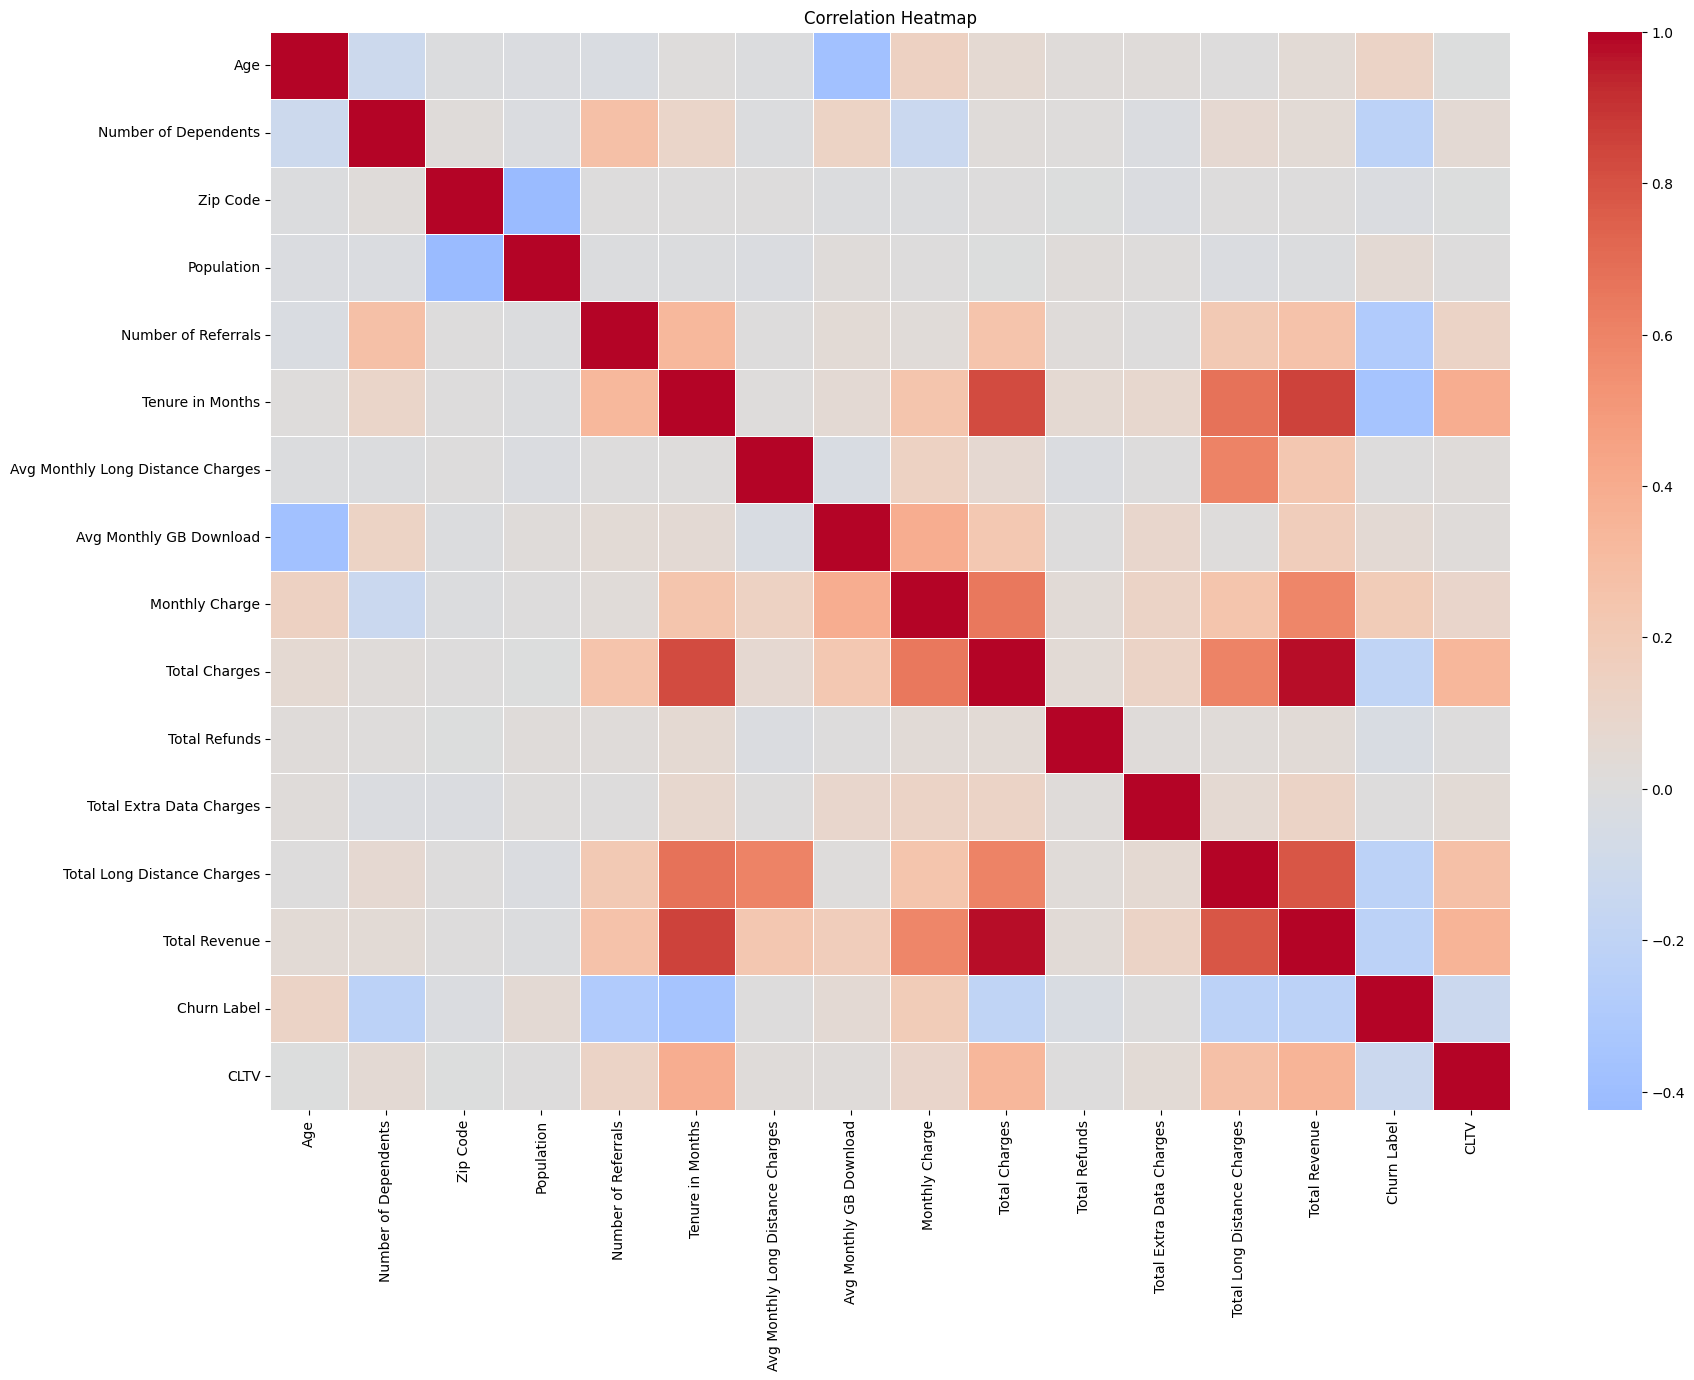

In [100]:
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(20,14))

sns.heatmap(
    df[numerical_cols].corr(),
    linewidths=0.5,
    cmap='coolwarm',
    center=0
)

plt.title("Correlation Heatmap")

plt.show()



In [101]:
from sklearn.feature_selection import SelectKBest,mutual_info_classif

In [102]:
ytrain.dtype

dtype('int64')

In [103]:
# not much collinarity between models, PCA seems redundant. using selectKbest
# selector=SelectKBest(
# score_func=lambda X, y: mutual_info_classif(X, y, random_state=42),
#     k=30
# )
# Xtrainselect=selector.fit_transform(Xtrainprocess,
#                                   ytrain)
# Xtestselect=selector.transform(Xtestprocess)

# Selectbest seems to drop the score rather than improving them

In [104]:
from sklearn.feature_selection import RFE
from sklearn.svm import LinearSVC



In [105]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    BaggingClassifier)

from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.svm import LinearSVC




In [106]:
from sklearn.feature_selection import RFECV


In [107]:
Xtrainselect=Xtrainprocess
Xtestselect=Xtestprocess

In [108]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)


In [109]:
# since the data is imbalanced I an using scale_pos_weight
ratio = (len(ytrain) - sum(ytrain)) / sum(ytrain)


In [110]:
models={
    'DecisionTree': DecisionTreeClassifier(
        random_state=42,
        class_weight='balanced'
    ),

    'RandomForest': RandomForestClassifier(
        random_state=42,
        class_weight='balanced'
    ),

        'AdaBoost': AdaBoostClassifier(
        random_state=42
    ),

    'GradientBoosting': GradientBoostingClassifier(
        random_state=42
    ),

    'Bagging': BaggingClassifier(
        random_state=42
    ),

    'XGBoost': XGBClassifier(
        eval_metric='logloss',
        random_state=42,
        scale_pos_weight=ratio
    ),
    'SVM':SVC(
        gamma='auto',class_weight='balanced', probability=True
    )
}

model: DecisionTreeClassifier(class_weight='balanced', random_state=42)
model: RandomForestClassifier(class_weight='balanced', random_state=42)
model: AdaBoostClassifier(random_state=42)
model: GradientBoostingClassifier(random_state=42)
model: BaggingClassifier(random_state=42)
model: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estima

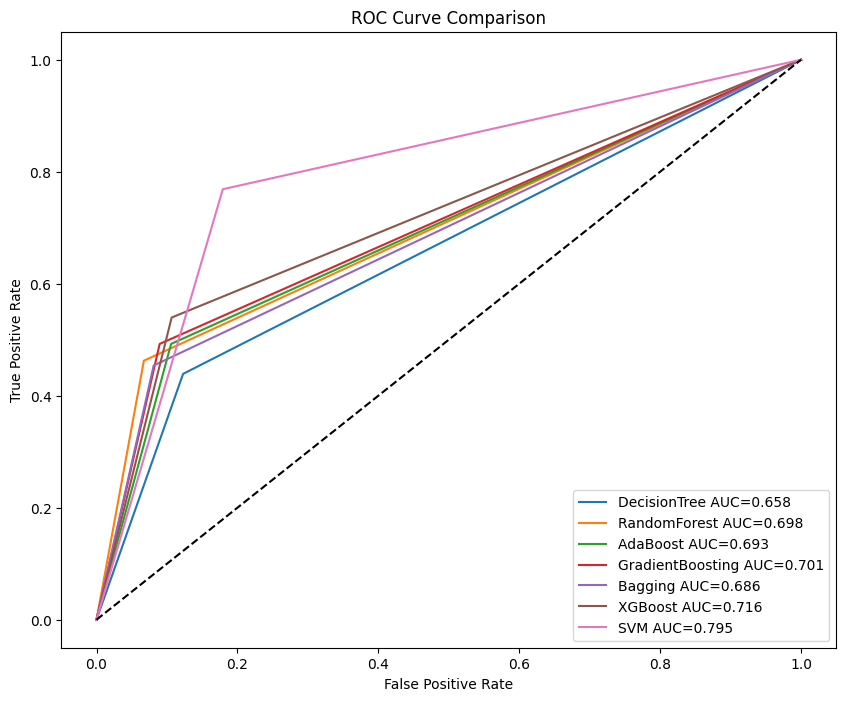

In [111]:
result=[]
plt.figure(figsize=(10,8))
for name,model in models.items():
    print(f"model: {model}")
    model.fit(Xtrainselect,ytrain)
    pred=model.predict(Xtestselect)

    accuracy=accuracy_score(ytest,pred)
    precision=precision_score(ytest,pred)
    recall=recall_score(ytest,pred)
    f1=f1_score(ytest,pred)
    auc=roc_auc_score(ytest,pred)
    result.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        auc
    ])
    fpr,tpr,_=roc_curve(ytest,pred)
    plt.plot(
        fpr,tpr,
        label=f'{name} AUC={auc:.3f}'
    )
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()



In [112]:
results_df = pd.DataFrame(
    result,
    columns=[
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1',
        'AUC'
    ]
)

results_df = results_df.sort_values(
    by='AUC',
    ascending=False
)

print(results_df)

              Model  Accuracy  Precision    Recall        F1       AUC
6               SVM  0.806928   0.607445  0.768737  0.678639  0.794724
5           XGBoost  0.799546   0.646154  0.539615  0.588098  0.716484
3  GradientBoosting  0.799546   0.664740  0.492505  0.565806  0.701430
1      RandomForest  0.808064   0.712871  0.462527  0.561039  0.697647
2          AdaBoost  0.787621   0.626703  0.492505  0.551559  0.693316
4           Bagging  0.795571   0.668770  0.453961  0.540816  0.686409
0      DecisionTree  0.760931   0.563187  0.438972  0.493381  0.658049


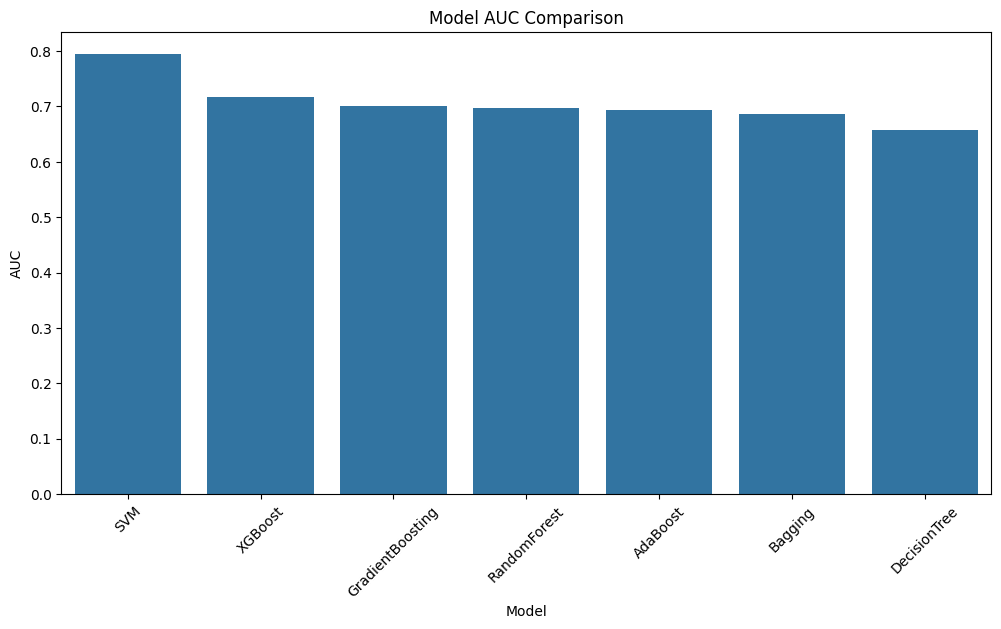

In [113]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='Model',
    y='AUC',
    data=results_df
)

plt.title("Model AUC Comparison")

plt.xticks(rotation=45)

plt.show()

In [114]:
from sklearn.model_selection import RandomizedSearchCV


In [115]:
xgb_params = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_search= RandomizedSearchCV(

    estimator=XGBClassifier(
        eval_metric='logloss',
        random_state=42,

        scale_pos_weight=ratio
    ),

    param_distributions=xgb_params,

    n_iter=10,

    cv=5,

    scoring='roc_auc',

    verbose=1,

    n_jobs=-1
)

xgb_search.fit(
    Xtrainselect,
    ytrain
)
print(xgb_search.best_params_)

print(xgb_search.best_score_)




Fitting 5 folds for each of 10 candidates, totalling 50 fits
{'subsample': 0.8, 'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
0.9468661457869277


In [116]:
best_model = xgb_search.best_estimator_


In [117]:
preds = best_model.predict(Xtestselect)



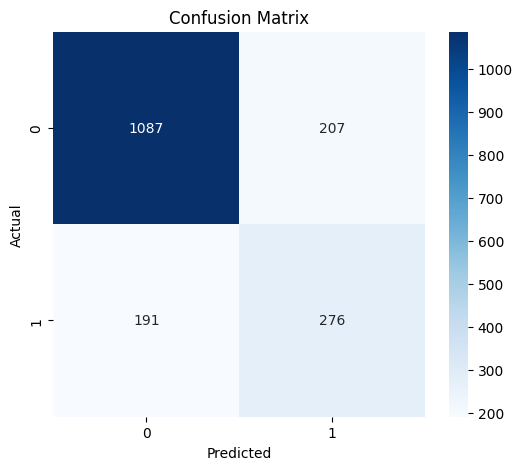

In [118]:
cm = confusion_matrix(ytest, preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()


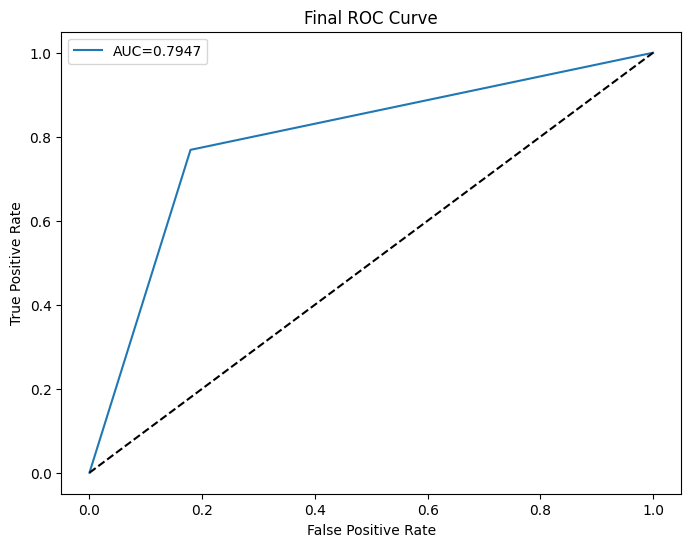

In [119]:
fpr, tpr, _ = roc_curve(ytest, pred)

auc = roc_auc_score(ytest, pred)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f'AUC={auc:.4f}'
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("Final ROC Curve")

plt.legend()

plt.show()


In [120]:
import shap


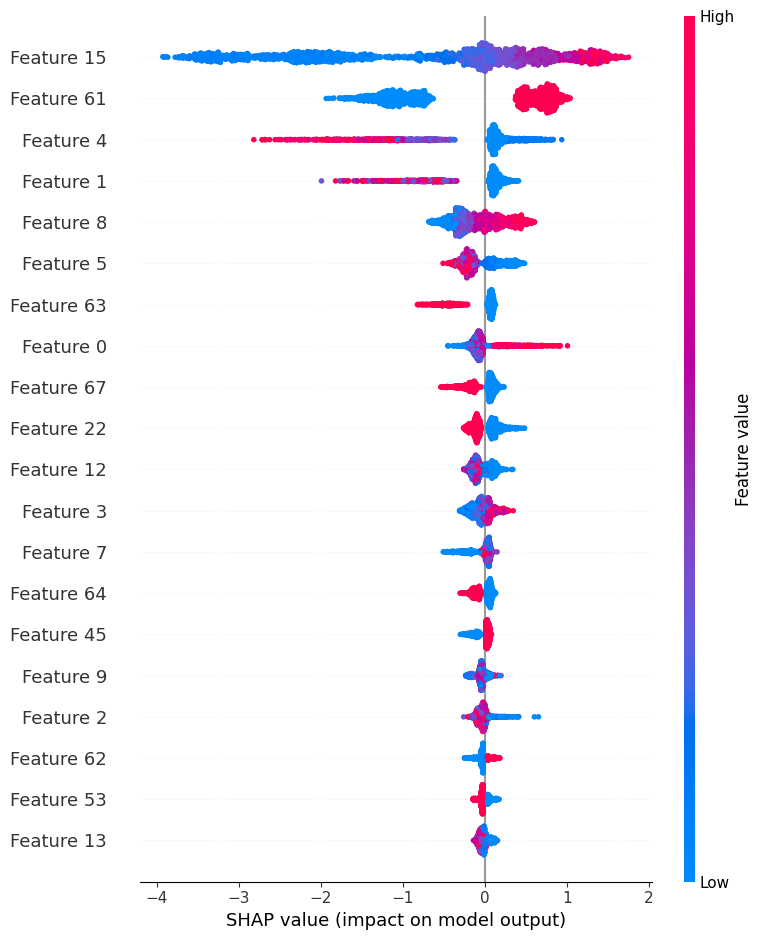

In [121]:
explainer= shap.TreeExplainer(
    best_model
)

shap_values = explainer.shap_values(
    Xtestselect
)

shap.summary_plot(
    shap_values,
    Xtestselect
)


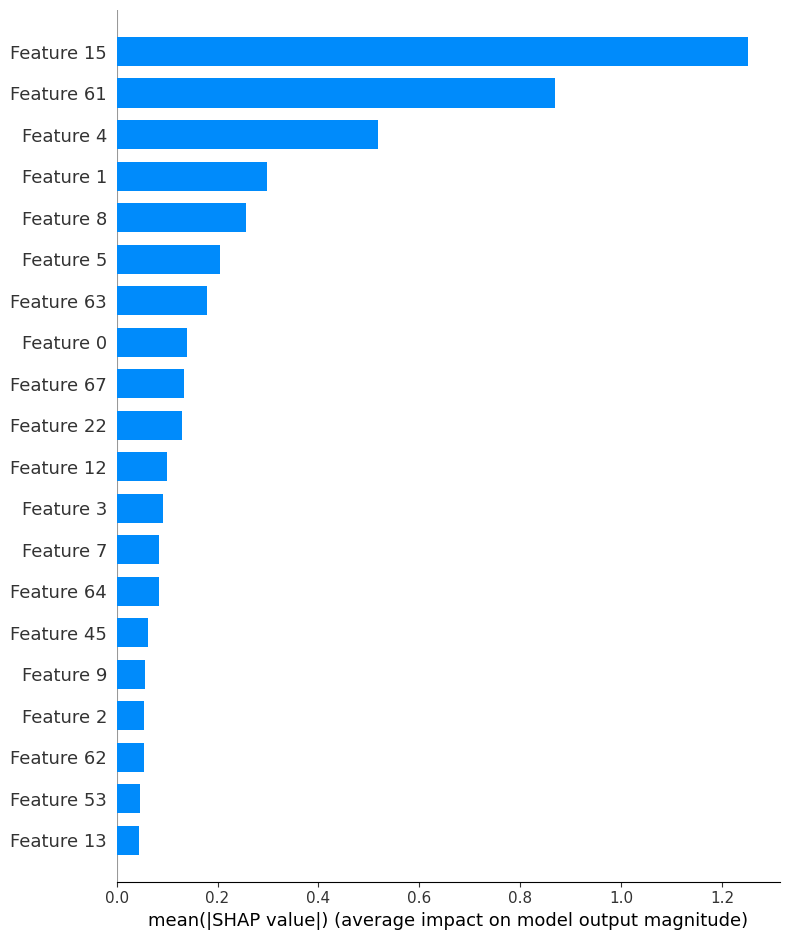

In [122]:
shap.summary_plot(
    shap_values,
    Xtestselect,
    plot_type='bar'
)


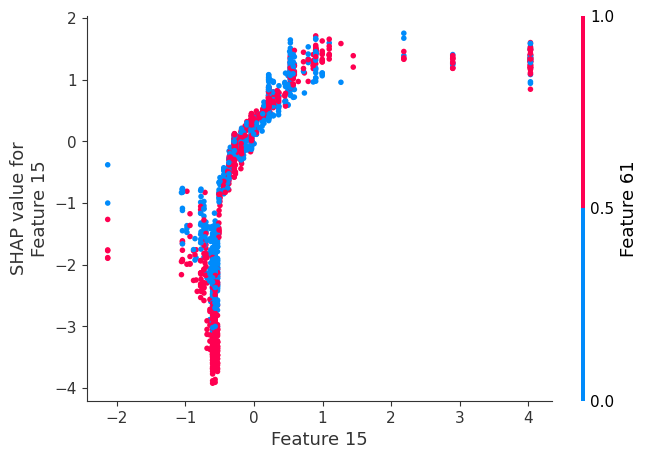

In [123]:
shap.dependence_plot(
    15,
    shap_values,
    Xtestselect
)


In [124]:
feature_names[15]

'num__CityEncoded'

Model was too dependent on satisfaction score. it seems satisfaction score is collected after a user leaves as removing it greatly changed model performance hinting that there was possible data leakage.

In [125]:
ranker = LinearSVC(
    penalty='l1',
    dual=False,
    class_weight='balanced',
    max_iter=10000,
    tol=1e-3  # Loosening the 'tolerance' makes it converge faster
)

rfecv = RFECV(estimator=ranker, step=1, cv=5, scoring='roc_auc')
final_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('feature_selection', rfecv),
    ('svc', SVC(kernel='rbf', class_weight='balanced', probability=True))
])

final_pipeline.fit(Xtrainprocess, ytrain)
y_prob = final_pipeline.predict_proba(Xtestprocess)[:, 1]
print("AUC with RFE + SVC:", roc_auc_score(ytest, y_prob))


AUC with RFE + SVC: 0.8758046526713641


In [126]:
from  sklearn.model_selection import cross_val_score
scores = cross_val_score(final_pipeline, Xtrainprocess, ytrain, cv=5, scoring='roc_auc')
print(f"Average CV AUC: {scores.mean():.4f} (+/- {scores.std():.4f})")

Average CV AUC: 0.9272 (+/- 0.0019)


In [127]:
from sklearn.metrics import classification_report, confusion_matrix

# 1. Generate predictions with the final pipeline
y_pred = final_pipeline.predict(Xtestprocess)
y_prob = final_pipeline.predict_proba(Xtestprocess)[:, 1]

# 2. Print the Classification Report
print("--- Classification Report ---")
print(classification_report(ytest, y_pred))

# 3. Print the Confusion Matrix (to see the True Positives/False Negatives)
print("--- Confusion Matrix ---")
print(confusion_matrix(ytest, y_pred))


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.90      0.84      0.87      1294
           1       0.63      0.74      0.68       467

    accuracy                           0.81      1761
   macro avg       0.76      0.79      0.77      1761
weighted avg       0.83      0.81      0.82      1761

--- Confusion Matrix ---
[[1086  208]
 [ 120  347]]


In [128]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay


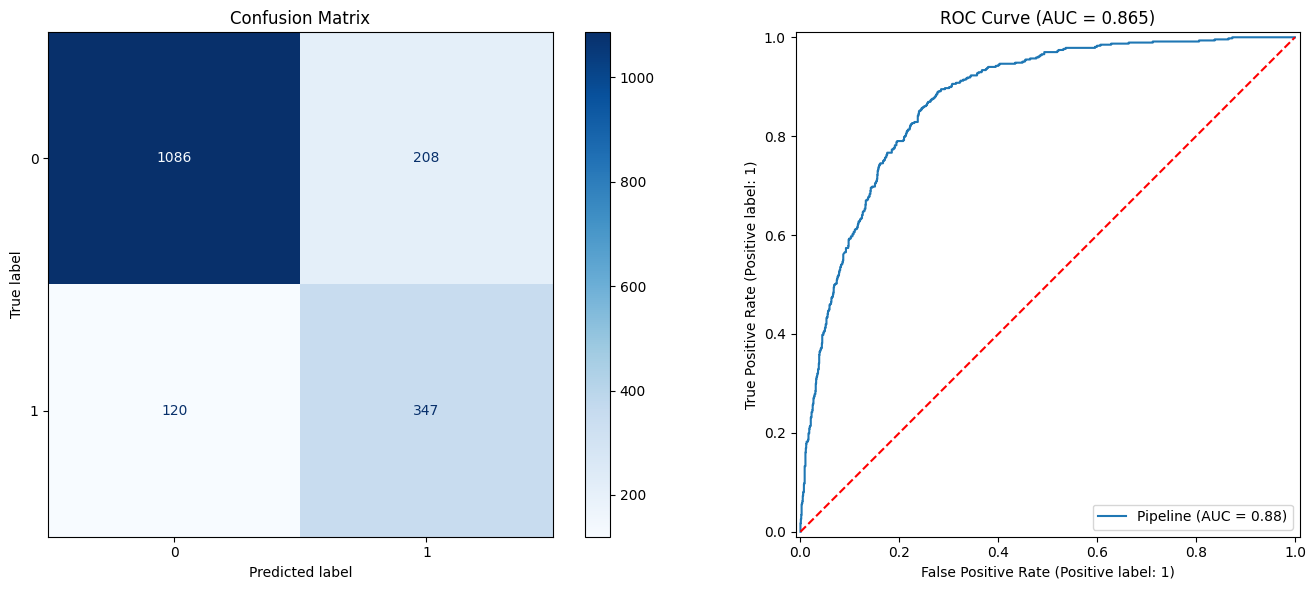

In [129]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# 1. Confusion Matrix Plot
# This shows you True Positives vs False Negatives
ConfusionMatrixDisplay.from_estimator(
    final_pipeline,
    Xtestprocess,
    ytest,
    ax=ax1,
    cmap='Blues'
)
ax1.set_title("Confusion Matrix")

# 2. ROC Curve Plot
# This shows your 0.86 AUC performance
RocCurveDisplay.from_estimator(
    final_pipeline,
    Xtestprocess,
    ytest,
    ax=ax2
)
ax2.plot([0, 1], [0, 1], linestyle='--', color='r') # Diagonal "random guess" line
ax2.set_title("ROC Curve (AUC = 0.865)")

plt.tight_layout()
plt.show()


In [130]:
from sklearn.inspection import permutation_importance

# Works on any model/pipeline
result = permutation_importance(final_pipeline, Xtestprocess, ytest, n_repeats=10, random_state=42)
# Access the importance values
print(result.importances_mean)

[ 0.00000000e+00  2.10107893e-03  0.00000000e+00  0.00000000e+00
  4.84383873e-02  2.14082907e-02  0.00000000e+00  0.00000000e+00
  1.05621806e-02  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  1.59000568e-03
  0.00000000e+00  0.00000000e+00  5.50823396e-03  0.00000000e+00
  0.00000000e+00  1.26064736e-02  0.00000000e+00  1.14707553e-02
  6.70073822e-03  0.00000000e+00  0.00000000e+00  9.48324815e-03
  0.00000000e+00  0.00000000e+00 -5.67859171e-05  0.00000000e+00
  9.08574673e-04  1.24929018e-03 -7.38216922e-04  0.00000000e+00
  2.27143668e-03  9.08574673e-04  0.00000000e+00  4.77001704e-03
  0.00000000e+00  0.00000000e+00  0.00000000e+00  4.42930153e-03
  0.00000000e+00  0.00000000e+00  7.32538330e-03  3.57751278e-03
  0.00000000e+00  0.00000000e+00  1.70357751e-04  4.08858603e-03
  0.00000000e+00  0.00000000e+00 -2.44179443e-03  0.00000000e+00
  2.89608177e-03  0.00000000e+00  5.90573538e-03  0.00000000e+00
  0.00000000e+00  4.37819